In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
jax.config.update("jax_enable_x64", True)
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
from amigo.stats import bin_data
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "svg.fonttype": "none",
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.plot import main_mosaic
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
    disco_regularised_loss_forecast_fn as drl_forecast_fn,
    oi_log_likelihood_forecast as oi_ll_forecast,
    latent_gaussian_prior as lgp,
)

In [2]:
master_key = jr.key(42)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [4]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


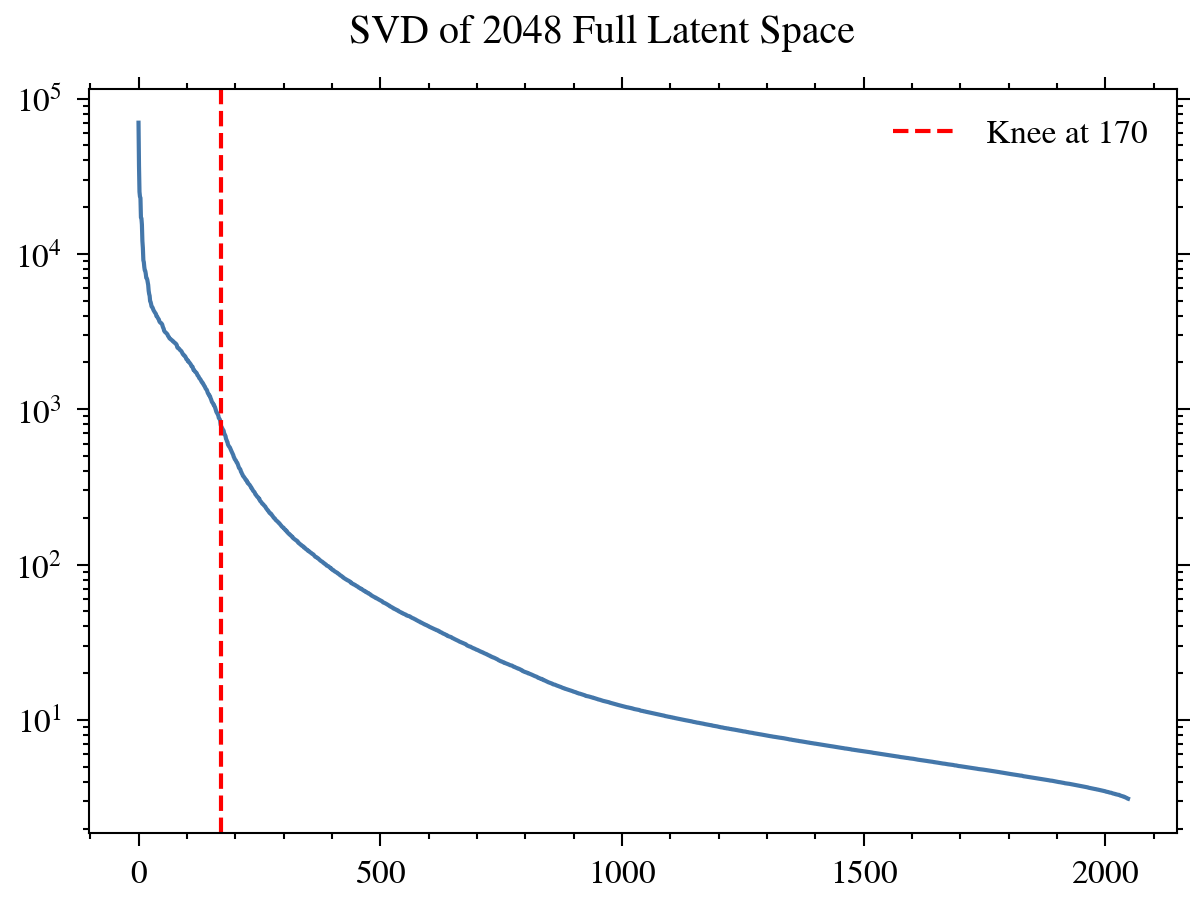

In [5]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of 2048 Full Latent Space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()


In [6]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")


def sum2unity(X):
    pix_sum = np.sum(X, axis=(1, 2), keepdims=True)
    norm_pix = X / pix_sum
    return norm_pix


sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae,
    sutured_ae.modules[1].layers + [sum2unity_layer],
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


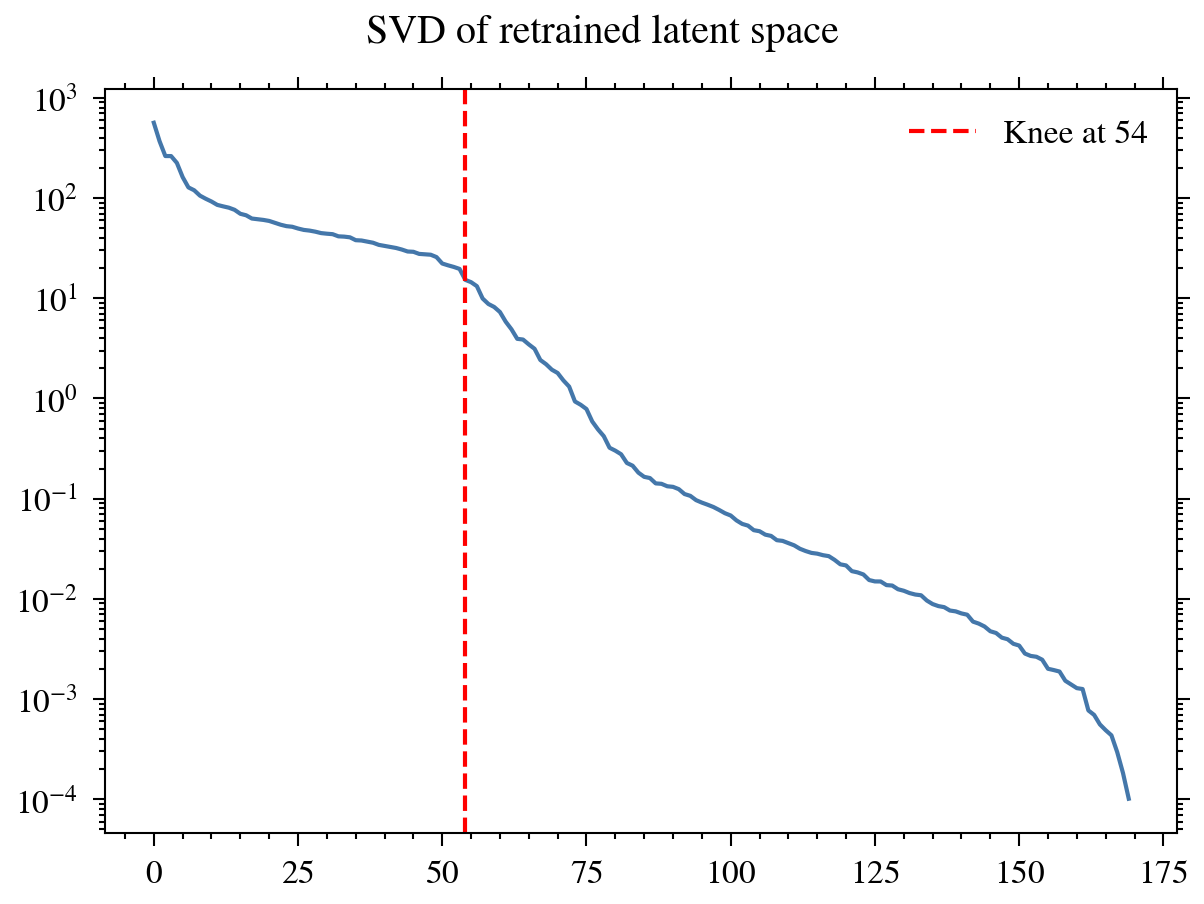

SVD Path: _data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz
Knee at 54


In [7]:
svd2_path = os.path.join(
    main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
)
svd2 = np.load(svd2_path)
k2 = KneeLocator(
    np.arange(len(svd2["s"])),
    svd2["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of retrained latent space")
ax.plot(svd2["s"], marker=",")
ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd2_path}")
print(f"Knee at {k2.knee}")

In [8]:
def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s**2 / 170)


embed_layer2 = eqx.nn.Lambda(
    lambda z: embed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer2],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s**2 / 170)) @ v + m


unembed_layer2 = eqx.nn.Lambda(
    lambda z: unembed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer2] + norm2_sutured_ae.modules[1].layers,  # [1:],
)
encoder, decoder = norm2_sutured_ae.modules

Text(0.5, 1.0, 'Initial Distribution | Sum: 1.0')

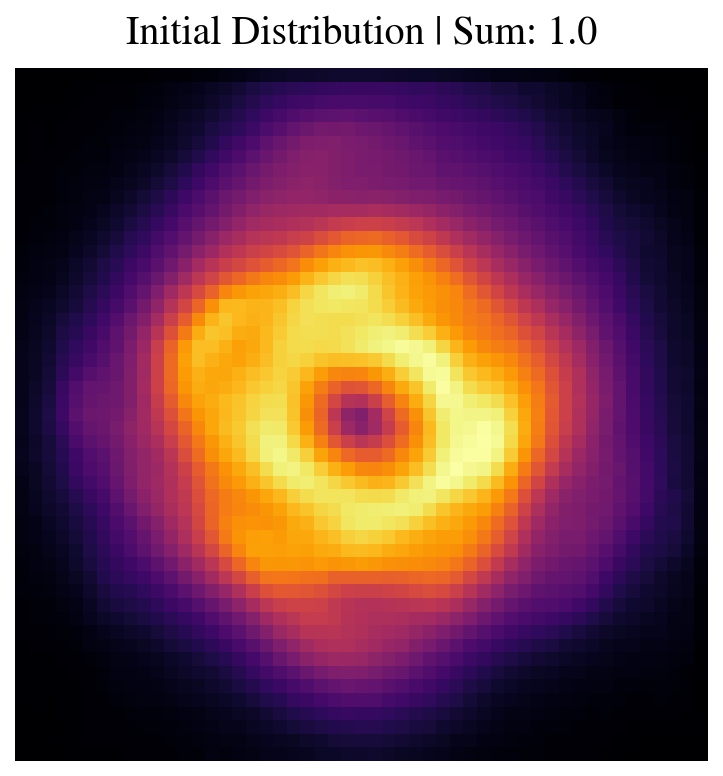

In [9]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)
init_dist = init_dist[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [40]:
filter = "F430M"
n_epochs = 1000
ld_lr = 1e-5
c_lr = 1e-10
prior=36

In [41]:
basis = AutoencoderBasis(norm2_sutured_ae)
# ois = [
#     PROIF(
#         oi_data,
#         key,
#         filter=key,
#     )
#     for key, oi_data in disco_PDS70.items()
# ]
oi_data = disco_PDS70[filter]
ois = [PROIF(oi_data, filter, filter=filter)]

baselines = np.sqrt(ois[0].u**2+ois[0].v**2)
base_flat = np.tile(baselines, ois[0].vis_mat.shape[0])
threshold = 0.005
optics_diameter = base_flat[ois[0].vis_mat.flatten() > threshold].max()
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

model = PRDM(
    ois=ois,
    distribution=init_dist,
    basis=basis,
    contrast=0.045,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            params["log_dist"][k] = log_dist
    return model_params.set("params", params), args


def grad_fn(model, grads, args):
    return grads, args


config = {
    # "log_dist": adam(1e-3, 0),
    "log_dist": adam(ld_lr, 0),  # adam(7.5e-4, 0),#adam(1e-3, 0),
    "contrast": sgd(c_lr, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}


args = {
    "reg_dict": {"latent_gaussian_prior": (prior, lgp)},
    "basis": basis,
}
trainer = amg.fitting.Trainer(
    loss_fn=disco_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache="_data/amigo/fisher",
)
trainer = trainer.update_fishers(
    model=model,
    exposures=ois,
    parameters=[],
)


result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epochs,
    batches=ois,
    args=args,
)
frito_model = result.model


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: -940.71
Estimated run time: 0:00:18
Full Time: 0:00:16
Final Loss: -1,832.46


In [45]:
def run_filter_bfgs(
    model, oi, filter_name, args, max_steps=500, rtol=1e-8, atol=1e-8
):
    x_map = {
        "log_dist": model.params["log_dist"][filter_name],
        "contrast": model.params["contrast"][filter_name],
    }

    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss

    forecast = np.array(oi(model))

    def neg_log_post_forecast(x, forecast):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = drl_forecast_fn(m, oi, forecast, args)
        return loss

    # DIAGNOSTICS
    f0 = float(neg_log_post(x_map))
    g0 = jax.grad(neg_log_post)(x_map)
    g0_flat, _ = ravel_pytree(g0)
    print(
        f"[{filter_name}] loss={f0:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g0_flat))):.3e}"
    )

    # HESSIAN

    print(f"[{filter_name}] computing Hessian...")
    H, _ = hessian(
        lambda x: neg_log_post_forecast(x, forecast),
        x_map,
        nbatches=1,
        jit=True,
    )

    def safe_fisher(H, floor_rel=1e-8):
        """Symmetrise H and reconstruct it with eigenvalues floored to be
        strictly positive. The result is PSD and safe to pass to eigen_projection."""
        H_sym = 0.5 * (H + H.T)
        vals, vecs = np.linalg.eigh(H_sym)
        floor = floor_rel * np.max(
            np.abs(vals)
        )  # use abs in case max is negative
        vals_clipped = np.clip(vals, floor, None)
        return (vecs * vals_clipped) @ vecs.T

    H_safe = safe_fisher(H)
    P = eigen_projection(fmat=H_safe)

    X0, unravel = ravel_pytree(x_map)
    n = X0.size

    def project_fn(u):
        return X0 + P @ u

    # Projected loss for BFGS
    @jax.jit
    def projected_loss(u, _args):
        return neg_log_post(unravel(project_fn(u)))

    # running bfgs
    print(f"[{filter_name}] running BFGS in latent space...")
    solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=rtol, atol=atol))

    u0 = np.zeros(n)

    sol = optx.minimise(
        projected_loss,
        solver,
        u0,
        args=None,
        max_steps=max_steps,
        throw=False,
    )

    # project back into param space
    u_opt = sol.value
    x_opt = unravel(project_fn(u_opt))

    # ---- Diagnostics after ----
    f1 = float(neg_log_post(x_opt))
    g1 = jax.grad(neg_log_post)(x_opt)
    g1_flat, _ = ravel_pytree(g1)
    print(
        f"[{filter_name}] after:  loss={f1:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g1_flat))):.3e}, "
        f"steps={int(sol.stats['num_steps'])}, "
        f"result={optx.RESULTS[sol.result]}"
    )

    # Write back into model
    new_log_dist = dict(model.params["log_dist"])
    new_log_dist[filter_name] = x_opt["log_dist"]
    new_contrast = dict(model.params["contrast"])
    new_contrast[filter_name] = x_opt["contrast"]
    new_params = dict(model.params)
    new_params["log_dist"] = new_log_dist
    new_params["contrast"] = new_contrast
    new_model = eqx.tree_at(lambda mm: mm.params, model, new_params)

    return {
        "model": new_model,
        "x_opt": x_opt,
        "u_opt": u_opt,
        "loss_before": f0,
        "loss_after": f1,
        "grad_inf_before": float(np.max(np.abs(g0_flat))),
        "grad_inf_after": float(np.max(np.abs(g1_flat))),
        "H_before": H,
        "P": P,
        "X0": X0,
        "sol": sol,
    }


bfgs_results = {}
for oi in ois:
    fname = oi.filter
    bfgs_result = run_filter_bfgs(
        frito_model, oi, fname, args, max_steps=1500, rtol=1e-12, atol=1e-12
    )
    bfgs_results[fname] = bfgs_result
bfgs_model = bfgs_results[filter]["model"]

[F430M] loss=-1.833e+03, ‖grad‖_inf=4.729e+03
[F430M] computing Hessian...
[F430M] running BFGS in latent space...
[F430M] after:  loss=-2.454e+03, ‖grad‖_inf=7.306e+00, steps=1500, result=The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.


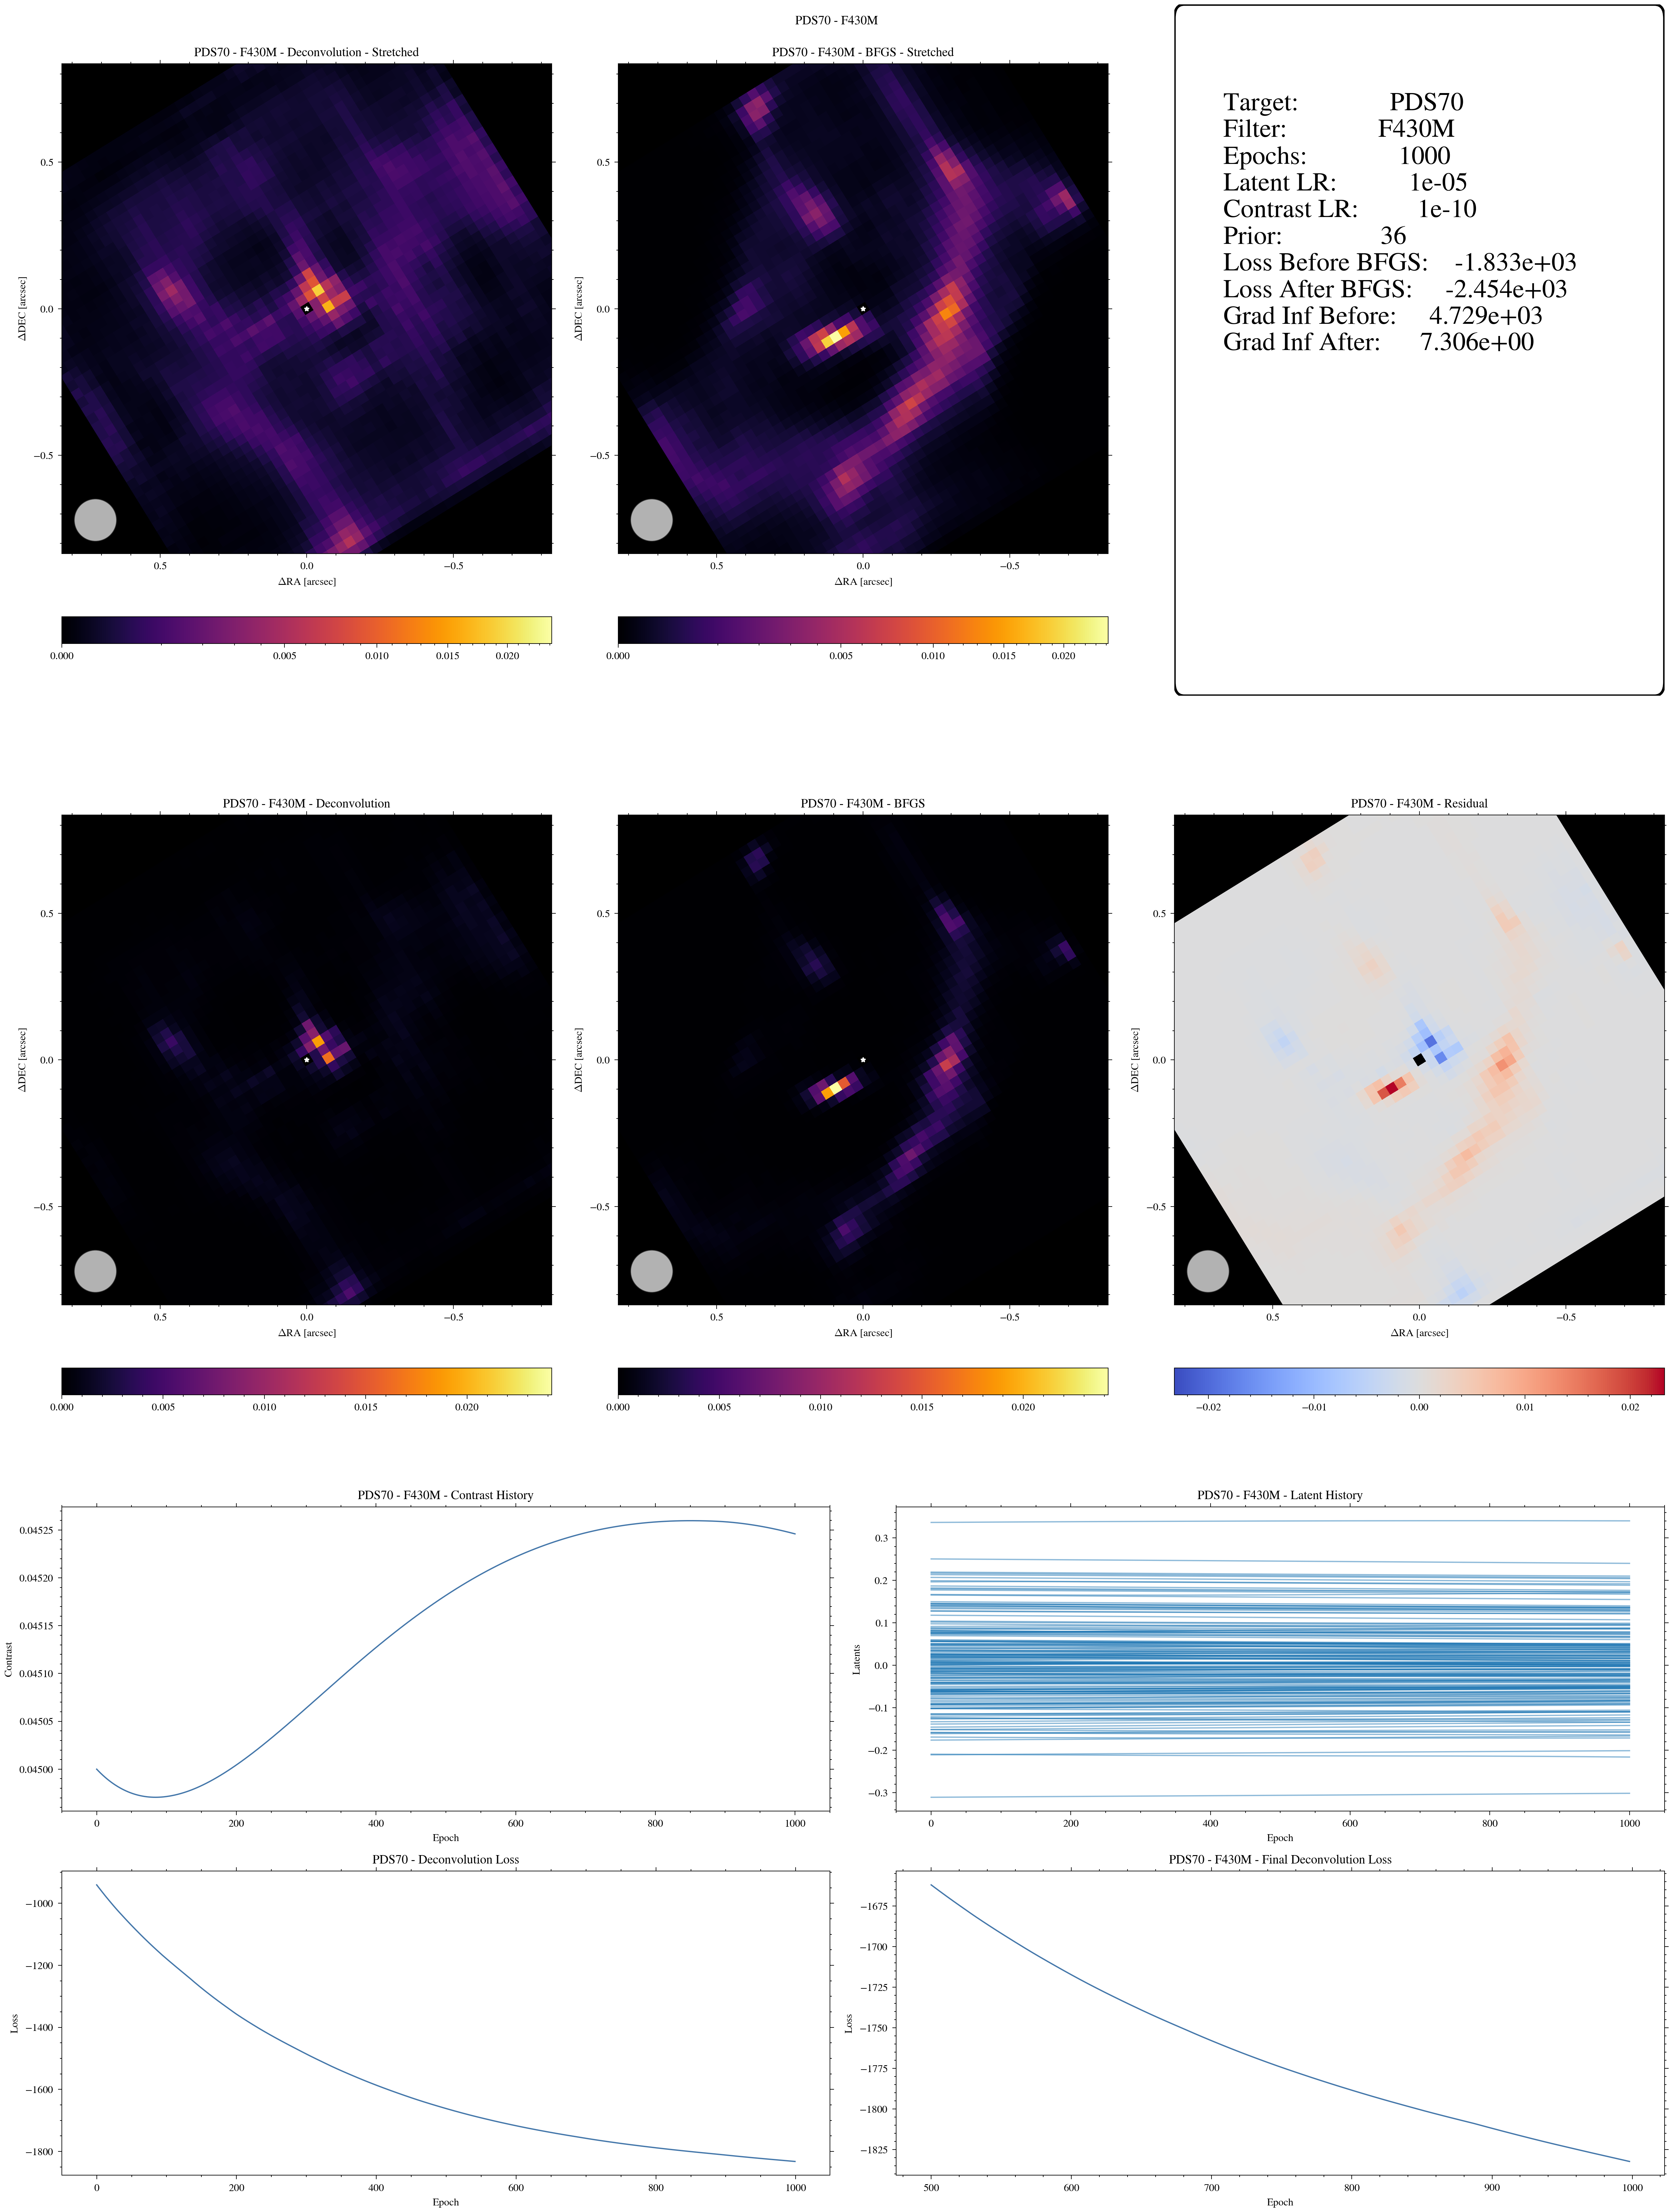

In [46]:
mosaic = main_mosaic(
    "PDS70",
    filter,
    ois,
    optics_diameter,
    frito_model,
    deconvolution_result=result,
    bfgs_model=bfgs_model,
    bfgs_result=bfgs_results[filter],
    epochs=n_epochs,
    log_dist_lr=ld_lr,
    contrast_lr=c_lr,
    prior=prior,
)

In [44]:
def laplace_approximation(model, oi, filter_name, args, x_opt=None):
    if x_opt is None:
        x_opt = {
            "log_dist": model.params["log_dist"][filter_name],
            "contrast": model.params["contrast"][filter_name],
        }

    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"]); new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"]); new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist; new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss

    f_map = float(neg_log_post(x_opt))
    g = jax.grad(neg_log_post)(x_opt)
    g_flat, _ = ravel_pytree(g)
    print(f"[{filter_name}] MAP loss={f_map:.3e}, grad_inf={float(np.max(np.abs(g_flat))):.3e}")

    print(f"[{filter_name}] computing Hessian at MAP...")
    H, _ = hessian(neg_log_post, x_opt, nbatches=1, jit=True)
    H_sym = 0.5 * (H + H.T)

    eigvals = np.linalg.eigvalsh(H_sym)
    n_pos = int(np.sum(eigvals > 0))
    print(f"[{filter_name}] H spectrum: {n_pos}/{len(eigvals)} positive, "
          f"min={float(eigvals.min()):.2e}, max={float(eigvals.max()):.2e}")

    floor_rel = 1e-8
    eigvals_clipped = np.clip(eigvals, floor_rel * np.max(eigvals), None)
    eigvecs = np.linalg.eigh(H_sym)[1]
    cov = (eigvecs * (1.0 / eigvals_clipped)) @ eigvecs.T
    cov = 0.5 * (cov + cov.T)

    X0, unravel = ravel_pytree(x_opt)
    sigma_flat = np.sqrt(np.diag(cov))
    sigma = unravel(sigma_flat)

    return {"x_map": x_opt, "H": H, "cov": cov, "sigma": sigma, "X0": X0,
            "unravel": unravel, "loss_map": f_map,
            "grad_inf_map": float(np.max(np.abs(g_flat)))}

laplace_results = {}
for oi in ois:
    fname = oi.filter
    bm = bfgs_results[fname]["model"]
    laplace_results[fname] = laplace_approximation(bm, oi, fname, args)

lap = laplace_results[filter]
unravel = lap["unravel"]
X0 = lap["X0"]
cov = lap["cov"]
print("joint X0 size:", X0.size)

[F430M] MAP loss=-2.454e+03, grad_inf=2.897e+01
[F430M] computing Hessian at MAP...
[F430M] H spectrum: 171/171 positive, min=1.25e+01, max=1.19e+07
joint X0 size: 171


In [26]:
# --- script-style dynamic detection ---
_test_flat = np.arange(X0.size, dtype=float)
_test_unraveled = unravel(_test_flat)
contrast_idx_script = int(np.asarray(_test_unraveled["contrast"]).item())
log_dist_idx_script = np.asarray(_test_unraveled["log_dist"]).astype(int)

print("SCRIPT detection:")
print("  contrast idx :", contrast_idx_script)
print("  log_dist idx shape:", log_dist_idx_script.shape, "dtype:", log_dist_idx_script.dtype)
print("  log_dist idx range:", int(log_dist_idx_script.min()), "..", int(log_dist_idx_script.max()))

# --- local-style hardcoded ---
n_latent = 170
contrast_idx_local = 0
log_dist_idx_local = np.arange(1, n_latent + 1)
print("LOCAL  hardcoded:")
print("  contrast idx :", contrast_idx_local)
print("  log_dist idx :", log_dist_idx_local[0], "..", log_dist_idx_local[-1],
      "shape", log_dist_idx_local.shape)

# --- do they agree? ---
same_shape = tuple(log_dist_idx_script.shape) == tuple(log_dist_idx_local.shape)
same_vals = same_shape and bool(np.all(np.asarray(log_dist_idx_script).ravel()
                                       == log_dist_idx_local))
print()
print("INDEX DETECTION MATCHES:" , same_shape and same_vals)
if not (same_shape and same_vals):
    print(">>> The script's dynamic detection disagrees with the hardcoded layout.")
    print(">>> This alone can make the script slice the wrong covariance block.")

SCRIPT detection:
  contrast idx : 0
  log_dist idx shape: (170,) dtype: int64
  log_dist idx range: 1 .. 170
LOCAL  hardcoded:
  contrast idx : 0
  log_dist idx : 1 .. 170 shape (170,)

INDEX DETECTION MATCHES: True


In [27]:
laplace_key, master_key = jr.split(master_key, 2)
n_draws = 1000

# --- marginal block, script-style indices ---
_ld_idx = log_dist_idx_script
X0_ld_A = X0[_ld_idx]
cov_ld_A = cov[np.ix_(_ld_idx, _ld_idx)]
cov_ld_A = 0.5 * (cov_ld_A + cov_ld_A.T)

v_A, U_A = np.linalg.eigh(cov_ld_A)
v_clip_A = np.clip(v_A, 0, None)          # <-- script: clip to exactly 0
L_A = U_A * np.sqrt(v_clip_A)

draws_ld_A = X0_ld_A[:, None] + L_A @ jr.normal(laplace_key, (X0_ld_A.size, n_draws))
draws_ld_A = draws_ld_A.T                  # (n_draws, 170)

# decode
decoded_draws_A = jax.vmap(decoder)(draws_ld_A)[:, 0, :, :]
decoded_draws_mean_A = np.mean(decoded_draws_A, axis=0)
decoded_draws_std_A = np.std(decoded_draws_A, axis=0)

# mean model: re-encode the mean IMAGE  (script behaviour)
def _build_model_with_log_dist(base_model, filter_name, log_dist_arr):
    new_log_dist = dict(base_model.params["log_dist"])
    new_log_dist[filter_name] = log_dist_arr
    new_params = dict(base_model.params)
    new_params["log_dist"] = new_log_dist
    return eqx.tree_at(lambda mm: mm.params, base_model, new_params)

laplace_mean_log_dist_A = encoder(decoded_draws_mean_A[None, ...])
laplace_mean_model_A = _build_model_with_log_dist(bfgs_model, filter,
                                                  laplace_mean_log_dist_A)
print("Version A done. eigenvalues clipped to zero:",
      int(np.sum(v_A <= 0)), "/", v_A.size)

Version A done. eigenvalues clipped to zero: 0 / 170


In [28]:
# --- marginal block, hardcoded local-style indices ---
_ld_idx_B = log_dist_idx_local
X0_ld_B = X0[_ld_idx_B]
cov_ld_B = cov[np.ix_(_ld_idx_B, _ld_idx_B)]
cov_ld_B = 0.5 * (cov_ld_B + cov_ld_B.T)

v_B, U_B = np.linalg.eigh(cov_ld_B)
floor_B = 1e-8 * float(np.max(v_B))        # <-- relative floor
v_clip_B = np.clip(v_B, floor_B, None)
L_B = U_B * np.sqrt(v_clip_B)

# reuse the SAME key so the only difference is the covariance factor,
# not the random draw
draws_ld_B = X0_ld_B[:, None] + L_B @ jr.normal(laplace_key, (X0_ld_B.size, n_draws))
draws_ld_B = draws_ld_B.T

decoded_draws_B = jax.vmap(decoder)(draws_ld_B)[:, 0, :, :]
decoded_draws_mean_B = np.mean(decoded_draws_B, axis=0)
decoded_draws_std_B = np.std(decoded_draws_B, axis=0)

# mean model: latent-space mean, no encoder round-trip
laplace_mean_log_dist_B = np.mean(draws_ld_B, axis=0)
laplace_mean_model_B = _build_model_with_log_dist(bfgs_model, filter,
                                                  laplace_mean_log_dist_B)
print("Version B done. eigenvalues below relative floor:",
      int(np.sum(v_B < floor_B)), "/", v_B.size)

Version B done. eigenvalues below relative floor: 0 / 170


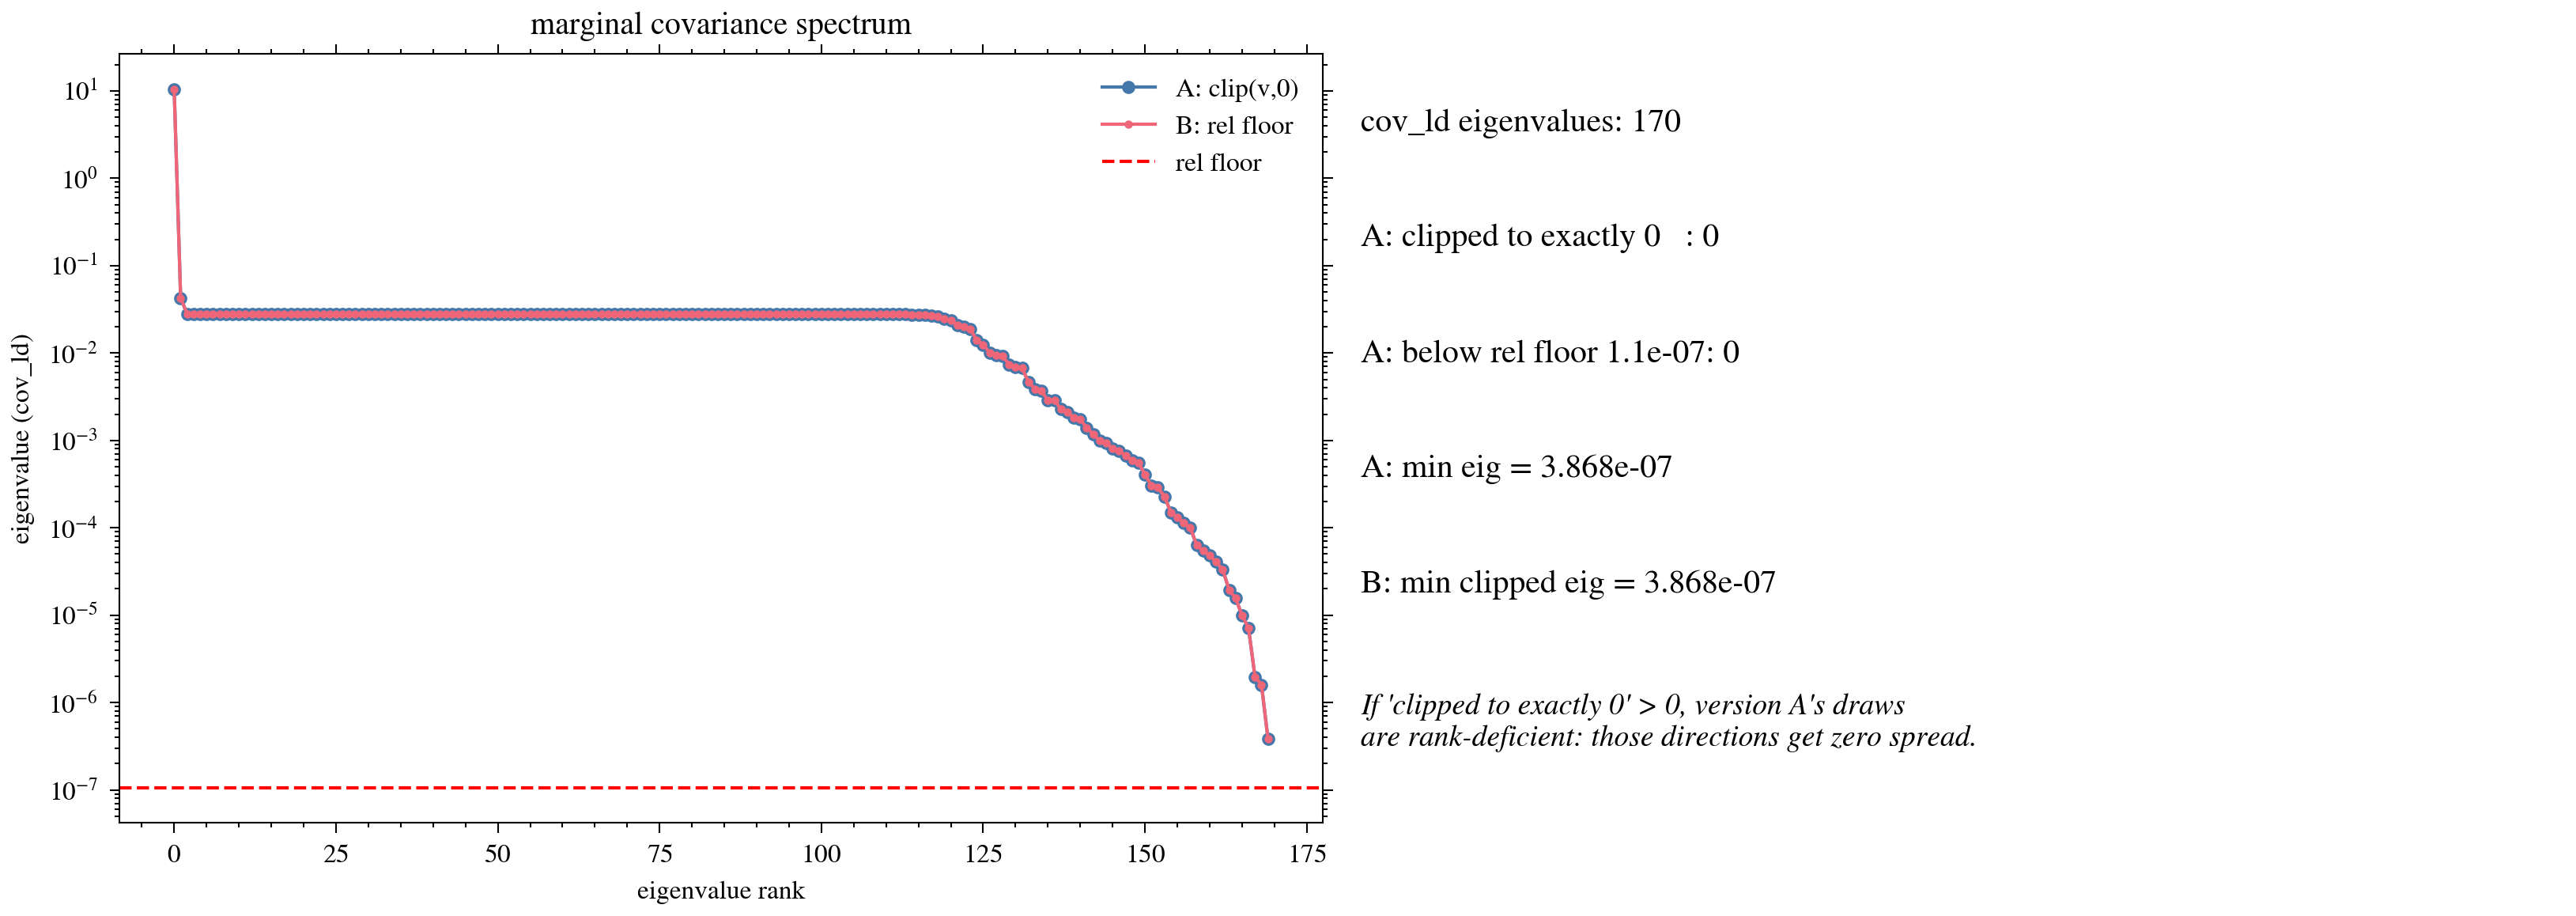

In [29]:
import numpy as onp
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].semilogy(onp.sort(onp.asarray(v_A))[::-1], "o-", ms=3, label="A: clip(v,0)")
ax[0].semilogy(onp.sort(onp.asarray(v_B))[::-1], ".-", ms=3, label="B: rel floor")
ax[0].axhline(floor_B, color="r", ls="--", lw=1, label="rel floor")
ax[0].set_xlabel("eigenvalue rank"); ax[0].set_ylabel("eigenvalue (cov_ld)")
ax[0].set_title("marginal covariance spectrum"); ax[0].legend()

# how many directions effectively killed in A
killed_A = int(np.sum(v_clip_A <= 0))
near_zero_A = int(np.sum(v_A < floor_B))
ax[1].axis("off")
ax[1].text(0.0, 0.9, f"cov_ld eigenvalues: {v_A.size}", fontsize=10)
ax[1].text(0.0, 0.75, f"A: clipped to exactly 0   : {killed_A}", fontsize=10)
ax[1].text(0.0, 0.60, f"A: below rel floor {floor_B:.1e}: {near_zero_A}", fontsize=10)
ax[1].text(0.0, 0.45, f"A: min eig = {float(v_A.min()):.3e}", fontsize=10)
ax[1].text(0.0, 0.30, f"B: min clipped eig = {float(v_clip_B.min()):.3e}", fontsize=10)
ax[1].text(0.0, 0.10,
           "If 'clipped to exactly 0' > 0, version A's draws\n"
           "are rank-deficient: those directions get zero spread.",
           fontsize=9, style="italic")
plt.tight_layout(); plt.show()

draws_ld_A per-dim std:  min=2.501e-02  max=1.013e+00  #(<1e-12)=0
draws_ld_B per-dim std:  min=2.501e-02  max=1.013e+00  #(<1e-12)=0

mean(draws_A) vs X0_ld : 0.014789393298998654
mean(draws_B) vs X0_ld : 0.014789393298998654


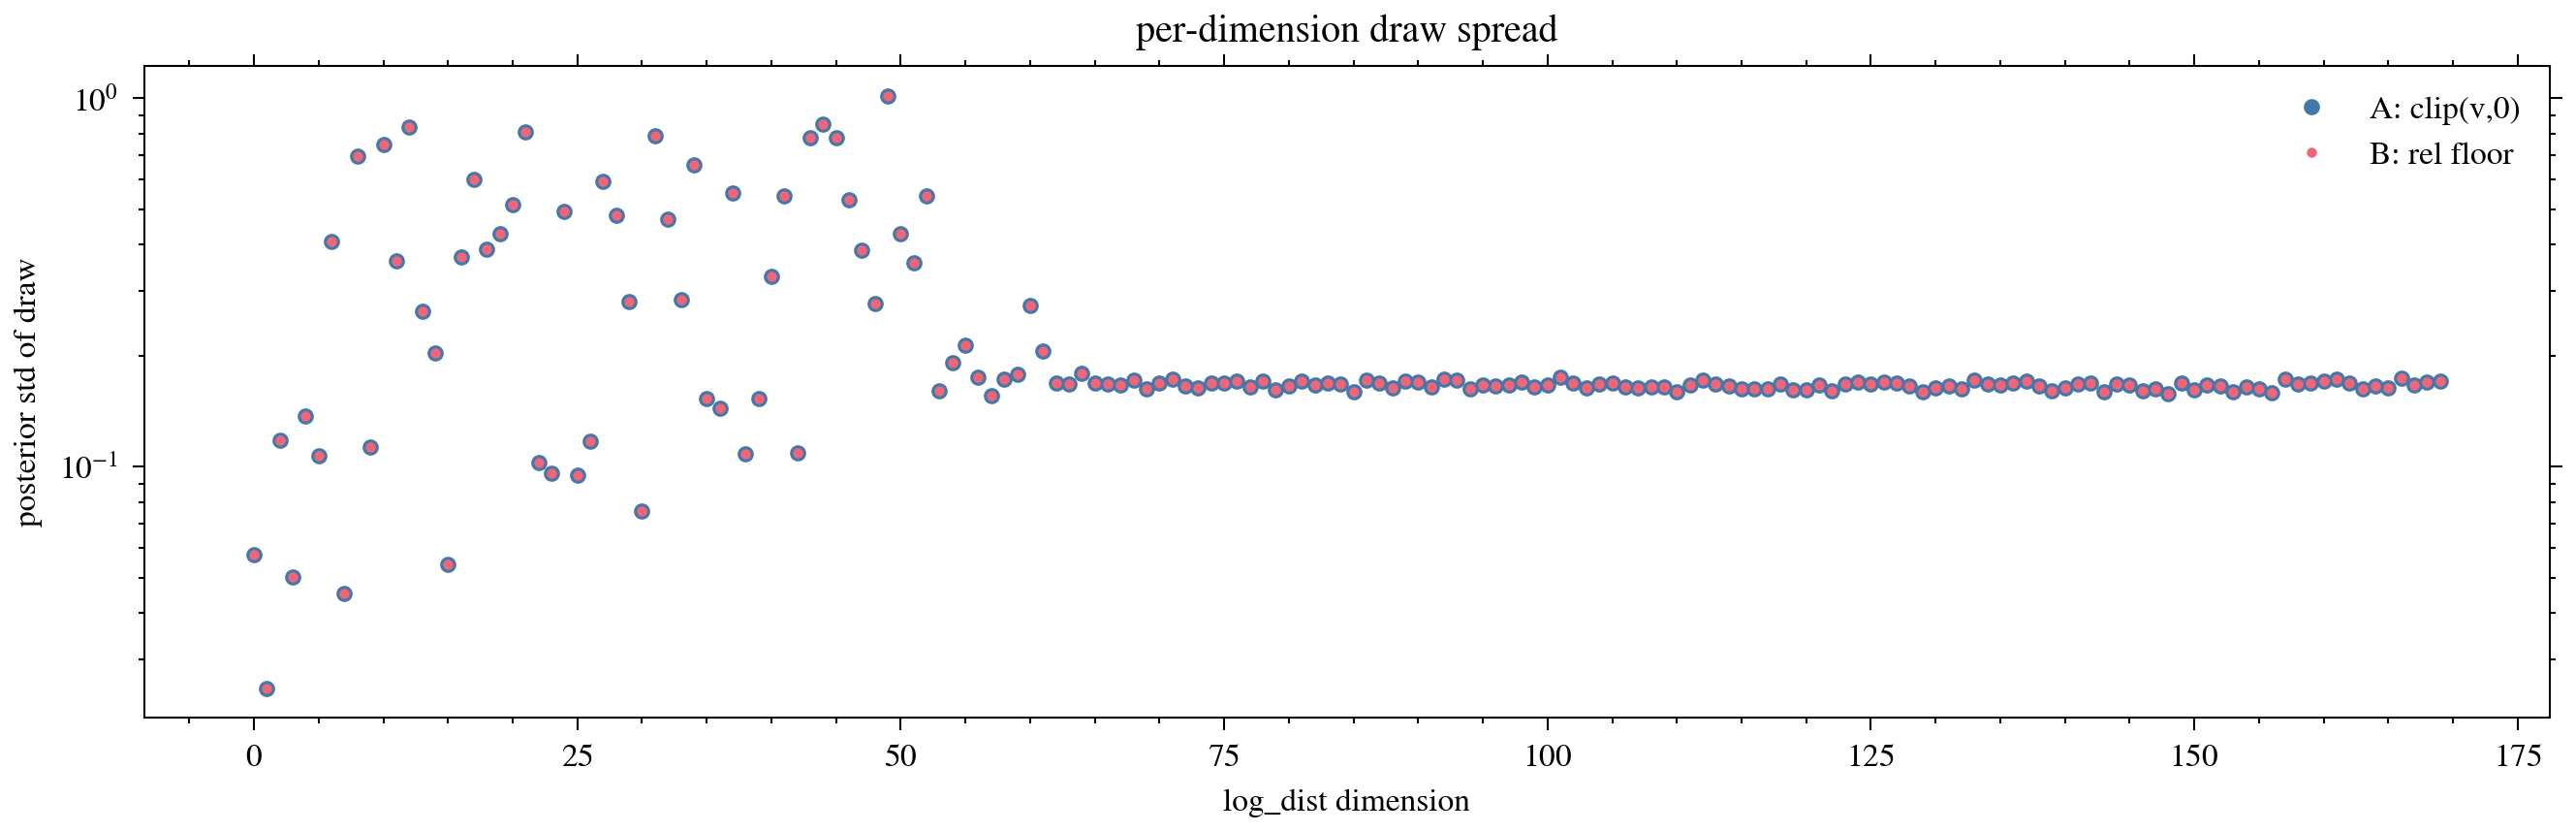

In [30]:
std_A = np.std(draws_ld_A, axis=0)
std_B = np.std(draws_ld_B, axis=0)

print("draws_ld_A per-dim std:  min={:.3e}  max={:.3e}  #(<1e-12)={}".format(
    float(std_A.min()), float(std_A.max()), int(np.sum(std_A < 1e-12))))
print("draws_ld_B per-dim std:  min={:.3e}  max={:.3e}  #(<1e-12)={}".format(
    float(std_B.min()), float(std_B.max()), int(np.sum(std_B < 1e-12))))
print()
print("mean(draws_A) vs X0_ld :", float(np.max(np.abs(draws_ld_A.mean(0) - X0_ld_A))))
print("mean(draws_B) vs X0_ld :", float(np.max(np.abs(draws_ld_B.mean(0) - X0_ld_B))))

fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(onp.asarray(std_A), "o", ms=3, label="A: clip(v,0)")
ax.semilogy(onp.asarray(std_B), ".", ms=3, label="B: rel floor")
ax.set_xlabel("log_dist dimension"); ax.set_ylabel("posterior std of draw")
ax.set_title("per-dimension draw spread"); ax.legend()
plt.tight_layout(); plt.show()

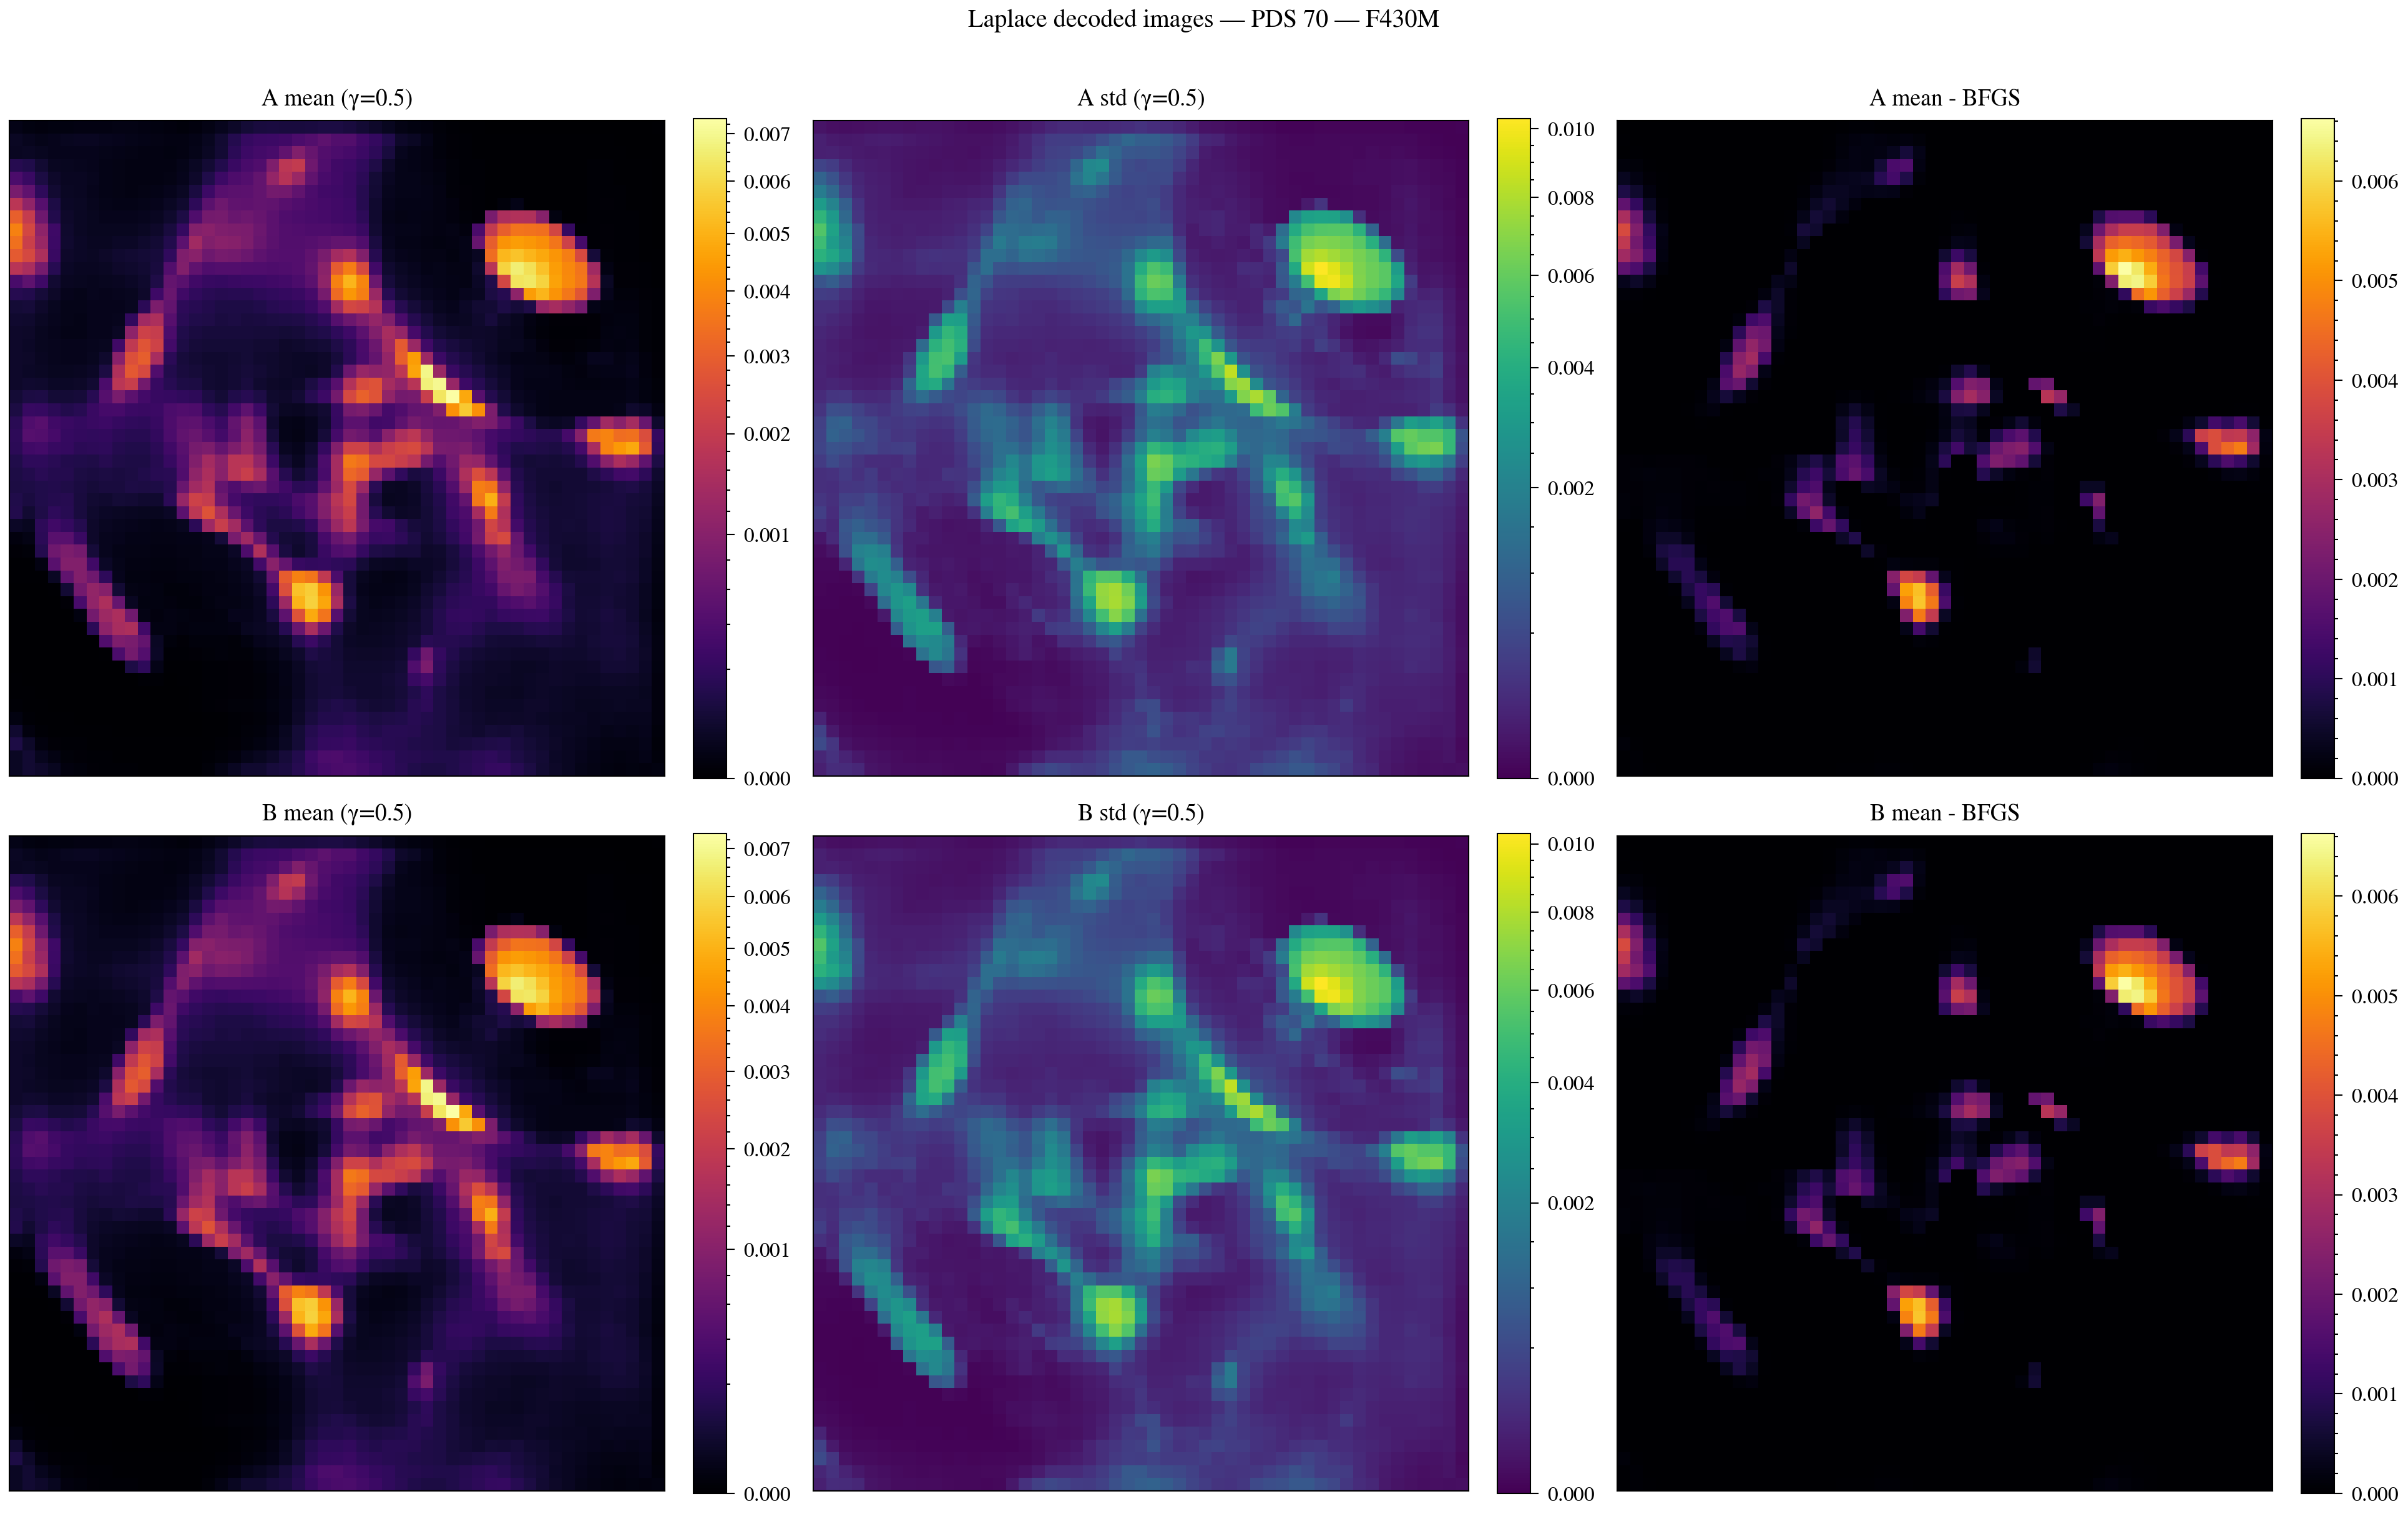

In [31]:
def _show(ax, img, title, cmap, gamma=0.5):
    img = onp.asarray(img)
    vmax = float(img.max())
    im = ax.imshow(img, norm=mpl.colors.PowerNorm(gamma=gamma, vmin=0.0, vmax=vmax), cmap=cmap)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
_show(axes[0, 0], decoded_draws_mean_A, "A mean (γ=0.5)", inferno)
_show(axes[0, 1], decoded_draws_std_A,  "A std (γ=0.5)", viridis)
_show(axes[0, 2], np.asarray(decoded_draws_mean_A) - np.asarray(bfgs_model(ois[0])),
      "A mean - BFGS", inferno, gamma=1.0)
_show(axes[1, 0], decoded_draws_mean_B, "B mean (γ=0.5)", inferno)
_show(axes[1, 1], decoded_draws_std_B,  "B std (γ=0.5)", viridis)
_show(axes[1, 2], np.asarray(decoded_draws_mean_B) - np.asarray(bfgs_model(ois[0])),
      "B mean - BFGS", inferno, gamma=1.0)
fig.suptitle(f"Laplace decoded images — PDS 70 — {filter}", y=1.01)
plt.tight_layout()